Converting binary data: 1101001

NRZ-L:
Time points: [0, 1, 1, 2, 2, 3, 3, 4, 4, 5]...
Signal levels: [1, 1, 1, 1, -1, -1, 1, 1, -1, -1]...

NRZ-I:
Time points: [0, 1, 1, 2, 2, 3, 3, 4, 4, 5]...
Signal levels: [-1, -1, 1, 1, 1, 1, -1, -1, -1, -1]...

RZ:
Time points: [0, 0.5, 0.5, 1, 1, 1.5, 1.5, 2, 2, 3]...
Signal levels: [1, 1, 0, 0, 1, 1, 0, 0, 0, 0]...

Manchester:
Time points: [0, 0.5, 0.5, 1, 1, 1.5, 1.5, 2, 2, 2.5]...
Signal levels: [-1, -1, 1, 1, -1, -1, 1, 1, 1, 1]...

Differential Manchester:
Time points: [0, 0.5, 0.5, 1, 1, 1.5, 1.5, 2, 2, 2.5]...
Signal levels: [1, 1, -1, -1, -1, -1, 1, 1, -1, -1]...


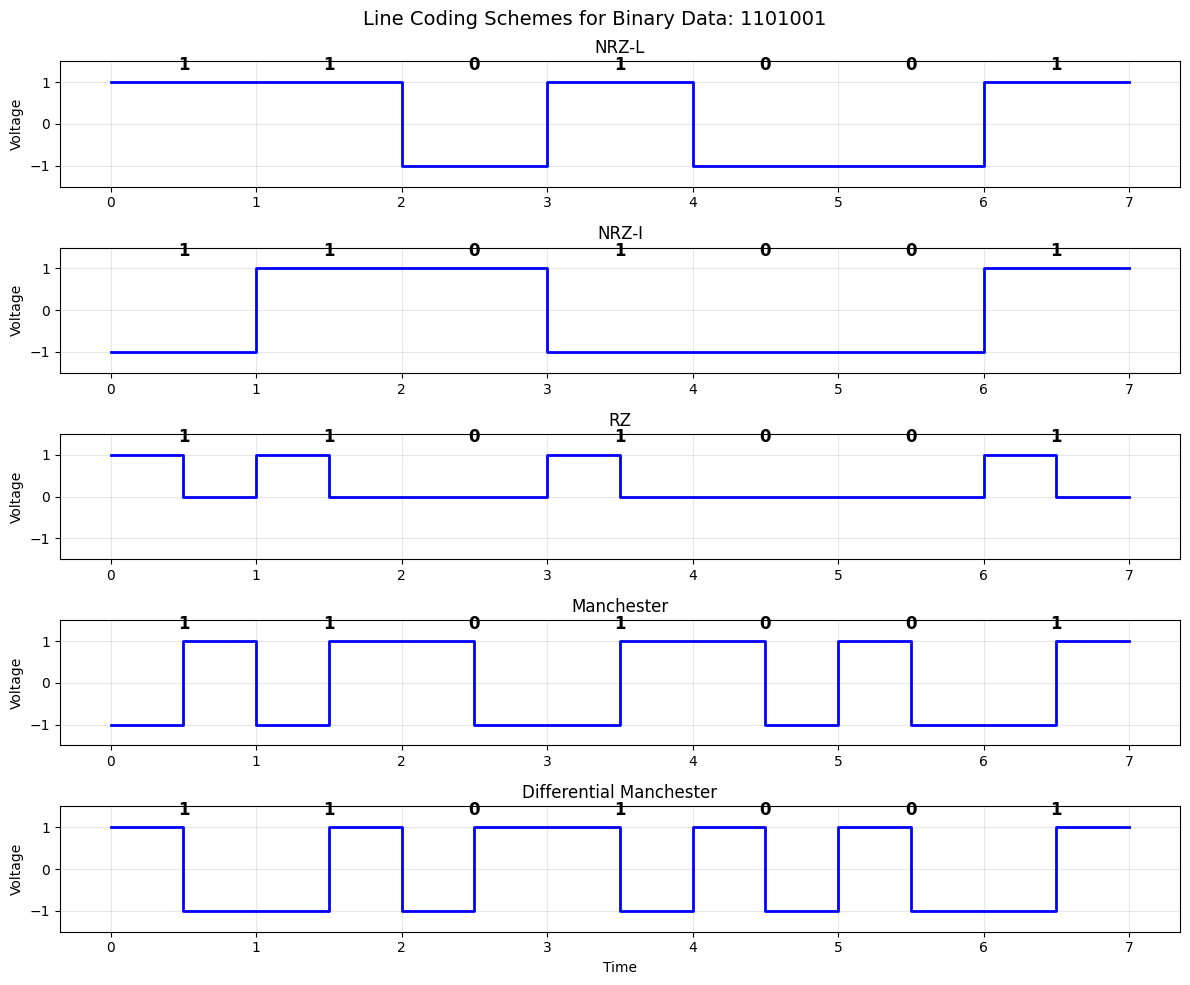

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class LineCoding:
    def __init__(self, bit_duration=1):
        self.bit_duration = bit_duration

    def nrz_l(self, binary_data):
        """Non-Return-to-Zero Level (NRZ-L)"""
        signal = []
        time = []
        current_time = 0

        for bit in binary_data:
            # For each bit, create time points
            t_start = current_time
            t_end = current_time + self.bit_duration

            # NRZ-L: 1 = +V, 0 = -V
            voltage = 1 if bit == '1' else -1

            time.extend([t_start, t_end])
            signal.extend([voltage, voltage])

            current_time = t_end

        return time, signal

    def nrz_i(self, binary_data):
        """Non-Return-to-Zero Inverted (NRZ-I)"""
        signal = []
        time = []
        current_time = 0
        current_level = 1  # Starting level

        for bit in binary_data:
            t_start = current_time
            t_end = current_time + self.bit_duration

            # NRZ-I: 1 = invert level, 0 = maintain level
            if bit == '1':
                current_level = -current_level

            time.extend([t_start, t_end])
            signal.extend([current_level, current_level])

            current_time = t_end

        return time, signal

    def rz(self, binary_data):
        """Return-to-Zero (RZ)"""
        signal = []
        time = []
        current_time = 0

        for bit in binary_data:
            t_mid = current_time + self.bit_duration/2
            t_end = current_time + self.bit_duration

            if bit == '1':
                # First half: +V, Second half: 0
                time.extend([current_time, t_mid, t_mid, t_end])
                signal.extend([1, 1, 0, 0])
            else:
                # Entire duration: 0
                time.extend([current_time, t_end])
                signal.extend([0, 0])

            current_time = t_end

        return time, signal

    def manchester(self, binary_data):
        """Manchester Encoding"""
        signal = []
        time = []
        current_time = 0

        for bit in binary_data:
            t_mid = current_time + self.bit_duration/2
            t_end = current_time + self.bit_duration

            if bit == '1':
                # 1: Low-to-High transition
                time.extend([current_time, t_mid, t_mid, t_end])
                signal.extend([-1, -1, 1, 1])
            else:
                # 0: High-to-Low transition
                time.extend([current_time, t_mid, t_mid, t_end])
                signal.extend([1, 1, -1, -1])

            current_time = t_end

        return time, signal

    def differential_manchester(self, binary_data):
        """Differential Manchester Encoding"""
        signal = []
        time = []
        current_time = 0
        current_level = 1  # Starting level

        for bit in binary_data:
            t_mid = current_time + self.bit_duration/2
            t_end = current_time + self.bit_duration

            if bit == '0':
                # 0: Transition at start of bit period
                current_level = -current_level
            # For '1': No transition at start

            # Always transition in middle
            first_half = current_level
            second_half = -current_level
            current_level = second_half  # Update for next bit

            time.extend([current_time, t_mid, t_mid, t_end])
            signal.extend([first_half, first_half, second_half, second_half])

            current_time = t_end

        return time, signal

    def plot_signals(self, binary_data):
        """Plot all line coding schemes for given binary data"""
        schemes = {
            'NRZ-L': self.nrz_l(binary_data),
            'NRZ-I': self.nrz_i(binary_data),
            'RZ': self.rz(binary_data),
            'Manchester': self.manchester(binary_data),
            'Differential Manchester': self.differential_manchester(binary_data)
        }

        fig, axes = plt.subplots(len(schemes), 1, figsize=(12, 10))
        fig.suptitle(f'Line Coding Schemes for Binary Data: {binary_data}', fontsize=14)

        for i, (scheme_name, (time, signal)) in enumerate(schemes.items()):
            axes[i].plot(time, signal, 'b-', linewidth=2)
            axes[i].set_title(scheme_name)
            axes[i].set_ylabel('Voltage')
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(-1.5, 1.5)

            # Add bit labels
            for j, bit in enumerate(binary_data):
                axes[i].text(j * self.bit_duration + self.bit_duration/2, 1.2,
                           bit, ha='center', va='bottom', fontsize=12, fontweight='bold')

        axes[-1].set_xlabel('Time')
        plt.tight_layout()
        plt.show()

# Example usage
def main():
    # Test binary data
    binary_data = "1101001"

    print(f"Converting binary data: {binary_data}")
    print("="*50)

    # Create line coding object
    encoder = LineCoding(bit_duration=1)

    # Convert to different schemes
    schemes = {
        'NRZ-L': encoder.nrz_l(binary_data),
        'NRZ-I': encoder.nrz_i(binary_data),
        'RZ': encoder.rz(binary_data),
        'Manchester': encoder.manchester(binary_data),
        'Differential Manchester': encoder.differential_manchester(binary_data)
    }

    # Print results
    for scheme_name, (time, signal) in schemes.items():
        print(f"\n{scheme_name}:")
        print(f"Time points: {time[:10]}...")  # Show first 10 points
        print(f"Signal levels: {signal[:10]}...")  # Show first 10 points

    # Plot all schemes
    encoder.plot_signals(binary_data)

    # Interactive input
    while True:
        user_input = input("\nEnter binary data (or 'quit' to exit): ").strip()
        if user_input.lower() == 'quit':
            break

        # Validate binary input
        if all(bit in '01' for bit in user_input) and user_input:
            encoder.plot_signals(user_input)
        else:
            print("Please enter valid binary data (only 0s and 1s)")

if __name__ == "__main__":
    main()